# Fake News Diffusion Simulation in Social Networks
### Proof of Concept

**Course:** Agent Systems 2026 &nbsp;•&nbsp; **Authors:** Piotr Branewski, Inhu Hwang

This notebook is a working prototype of our multi-agent simulation of fake-news
diffusion. The aim at this stage is to show that the core idea runs end to end — not
to deliver a complete or optimized system.

**What the prototype does**

1. Builds a Barabási–Albert scale-free network of 5,000 agents with an echo-chamber
   belief structure.
2. Populates it with three agent types — regular users, social bots and fact-checkers.
3. Spreads a single fake-news item through an extended SIR model with an added
   *Dormant* state.
4. Lets each agent decide whether to share the content via a weighted probability rule.
5. Measures the cascade and visualizes it (infection curve, network map).
6. Compares the run against a counterfactual with no fact-checkers, and against
   different intervention timings and critical-thinking levels.

We model the diffusion of a **single** news item, so each agent holds one state from
`{S, I, D, R}` at a time.

## 1. Setup

In [2]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

RNG_SEED = 1
plt.rcParams["figure.dpi"] = 110
print("ready — networkx", nx.__version__, "| numpy", np.__version__)

ready — networkx 3.6.1 | numpy 2.4.5


## 2. The information item

A `Message` represents the fake news being spread. It carries a *belief lean* — where
on the opinion axis the narrative sits — and a *virality* score for how
attention-grabbing it is regardless of content.

In [3]:
@dataclass
class Message:
    belief_alignment: float = 0.7   # where the narrative sits on the [-1, 1] belief axis
    virality: float = 0.6           # how attention-grabbing the item is, in [0, 1]

## 3. Agents

All three agent types share one `Agent` class and are told apart by the `kind` field.
An agent has a political belief, a level of critical thinking, a susceptibility to
influence and a trustworthiness as a source. Its state is one of Susceptible, Infected,
Dormant or Recovered.

In [4]:
S, I, D, R = "S", "I", "D", "R"   # Susceptible, Infected, Dormant, Recovered

@dataclass
class Agent:
    uid: int
    kind: str                       # "user", "bot" or "checker"
    belief: float = 0.0             # political leaning in [-1, 1]
    critical_thinking: float = 0.5  # resistance to sharing, in [0, 1]
    susceptibility: float = 0.5     # ease of being influenced, in [0, 1]
    trustworthiness: float = 0.5    # how much others trust this agent, in [0, 1]
    state: str = S
    active: bool = True             # fact-checkers start inactive
    credibility: float = 0.7        # a fact-checker's chance of correcting a neighbor

## 4. The sharing decision

When an infected neighbor exposes an agent to the news, the agent decides whether to
pass it on. The probability blends four factors:

$$P_\text{raw} = w_1\,\text{Alignment} + w_2\,\text{Trust} + w_3\,\text{Virality} - w_4\,\text{CriticalThinking}$$

Alignment measures how close the agent's belief is to the narrative,
$\text{Alignment} = 1 - |b_\text{agent} - b_\text{message}| / 2$. The result is clamped
to $[0, 1]$ and scaled by the agent's susceptibility. When several infected neighbors
expose the agent at once, the per-neighbor probabilities compound:
$P_\text{eff} = 1 - (1 - P)^n$.

In [5]:
WEIGHTS = dict(w1=0.40, w2=0.25, w3=0.30, w4=0.55)

def p_share(agent, msg, infected_neighbors, w=WEIGHTS):
    """Probability that `agent` shares the news after one exposure."""
    alignment = 1.0 - abs(agent.belief - msg.belief_alignment) / 2.0
    trust = np.mean([n.trustworthiness for n in infected_neighbors])
    raw = (w["w1"] * alignment + w["w2"] * trust + w["w3"] * msg.virality
           - w["w4"] * agent.critical_thinking)
    return float(np.clip(raw, 0.0, 1.0) * agent.susceptibility)

# sanity check: an aligned, uncritical user against an opposed, skeptical one
believer = Agent(0, "user", belief=0.7, critical_thinking=0.1, susceptibility=0.8)
skeptic  = Agent(1, "user", belief=-0.7, critical_thinking=0.9, susceptibility=0.3)
source   = [Agent(2, "bot", trustworthiness=0.4)]
news     = Message()
print(f"aligned, uncritical user -> P(share) = {p_share(believer, news, source):.3f}")
print(f"opposed, skeptical user  -> P(share) = {p_share(skeptic, news, source):.3f}")

aligned, uncritical user -> P(share) = 0.500
opposed, skeptical user  -> P(share) = 0.000


## 5. Building the network

`build_model` creates the graph and places the agents on it:

* a Barabási–Albert scale-free graph, whose high-degree hubs act as influencers;
* regular users whose beliefs are either polarized into two camps (`echo_strength > 0`)
  or spread out uniformly;
* social bots (~2% of the network), placed on the largest hubs or at random, and
  infected from the start;
* fact-checkers, also placed on hubs but inactive until the intervention step.

In [6]:
def build_model(n=5000, m=3, bot_ratio=0.02, n_checkers=150, echo_strength=0.7,
                bot_target="hub", ct_a=2.0, ct_b=2.0, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    g = nx.barabasi_albert_graph(n, m, seed=seed)
    degree = dict(g.degree())
    ranked = sorted(degree, key=degree.get, reverse=True)

    agents = {}
    for node in g.nodes():
        if echo_strength > 0:                       # two polarized belief camps
            center = rng.choice([-echo_strength, echo_strength])
            belief = float(np.clip(rng.normal(center, 0.25), -1, 1))
        else:                                       # beliefs spread out uniformly
            belief = float(rng.uniform(-1, 1))
        agents[node] = Agent(
            uid=node, kind="user", belief=belief,
            critical_thinking=float(np.clip(rng.beta(ct_a, ct_b), 0, 1)),
            susceptibility=float(np.clip(rng.beta(2, 3), 0, 1)),
            trustworthiness=float(np.clip(rng.beta(3, 2), 0, 1)))

    n_bots = max(1, int(n * bot_ratio))
    bot_nodes = (ranked[:n_bots] if bot_target == "hub"
                 else list(rng.choice(ranked, n_bots, replace=False)))
    for node in bot_nodes:
        agents[node] = Agent(uid=node, kind="bot", belief=0.9, critical_thinking=0.0,
                             susceptibility=0.0, trustworthiness=0.35, state=I)

    for node in [x for x in ranked if agents[x].kind == "user"][:n_checkers]:
        agents[node].kind = "checker"
        agents[node].active = False

    return g, agents, bot_nodes

g, agents, bots = build_model()
print(f"network: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges")
print(f"agents : {sum(a.kind == 'user' for a in agents.values())} users, "
      f"{len(bots)} bots, {sum(a.kind == 'checker' for a in agents.values())} checkers")
print(f"largest hub degree: {max(dict(g.degree()).values())}")

network: 5000 nodes, 14991 edges
agents : 4750 users, 100 bots, 150 checkers
largest hub degree: 163


## 6. The simulation loop

Each call to `run` simulates one fake-news cascade. On every timestep:

1. once the intervention step is reached, the fact-checkers switch on;
2. every susceptible or dormant agent looks at its infected neighbors and rolls the
   sharing probability — on success it becomes Infected, otherwise it lapses into
   Dormant. A dormant agent can still be infected later, at a reduced chance;
3. active fact-checkers correct infected neighbors into the Recovered state;
4. the population is counted.

A timestep `t` is an abstract simulation tick — one round of decisions — and does not
correspond to a real hour or day.

In [7]:
def run(g, agents, msg, steps=100, checker_activation=30, seed=RNG_SEED):
    rng = np.random.default_rng(seed + 999)
    history = []
    for t in range(steps):
        if t == checker_activation:
            for a in agents.values():
                if a.kind == "checker":
                    a.active = True

        new_state = {}
        for node, a in agents.items():
            if a.kind == "bot" or a.state == R:
                continue
            if a.kind == "checker" and a.active:
                continue
            infected = [agents[nb] for nb in g.neighbors(node)
                        if agents[nb].state == I or agents[nb].kind == "bot"]
            if not infected:
                continue
            p = p_share(a, msg, infected)
            if a.state == D:                       # already shrugged the news off once
                p *= 0.5
            p_eff = 1.0 - (1.0 - p) ** len(infected)
            if rng.random() < p_eff:
                new_state[node] = I
            elif a.state == S:
                new_state[node] = D

        for node, a in agents.items():             # fact-checkers correct their neighbors
            if a.kind == "checker" and a.active:
                for nb in g.neighbors(node):
                    if agents[nb].kind == "user" and agents[nb].state == I:
                        if rng.random() < a.credibility:
                            new_state[nb] = R

        for node, st in new_state.items():
            agents[node].state = st

        counts = {S: 0, I: 0, D: 0, R: 0}
        for a in agents.values():
            if a.kind != "bot":
                counts[a.state] += 1
        counts["t"] = t
        history.append(counts)
    return pd.DataFrame(history)

## 7. Baseline run

A single fake-news cascade seeded by the bots, with the fact-checkers switching on at
timestep 30.

In [8]:
msg = Message(belief_alignment=0.7, virality=0.6)
g, agents, bots = build_model(seed=RNG_SEED)
df = run(g, agents, msg, steps=100, checker_activation=30, seed=RNG_SEED)

population = sum(a.kind != "bot" for a in agents.values())
print(f"population (excluding bots) : {population}")
print(f"peak infected               : {df['I'].max()} "
      f"({100 * df['I'].max() / population:.1f}%)")
print(f"still infected at the end   : {df['I'].iloc[-1]}")
print(f"recovered at the end        : {df['R'].iloc[-1]}")
print(f"dormant at the end          : {df['D'].iloc[-1]}")
df.tail(3)

population (excluding bots) : 4900
peak infected               : 4022 (82.1%)
still infected at the end   : 2705
recovered at the end        : 1714
dormant at the end          : 481


,S,I,D,R,t
97,0,2704,482,1714,97
98,0,2705,481,1714,98
99,0,2705,481,1714,99


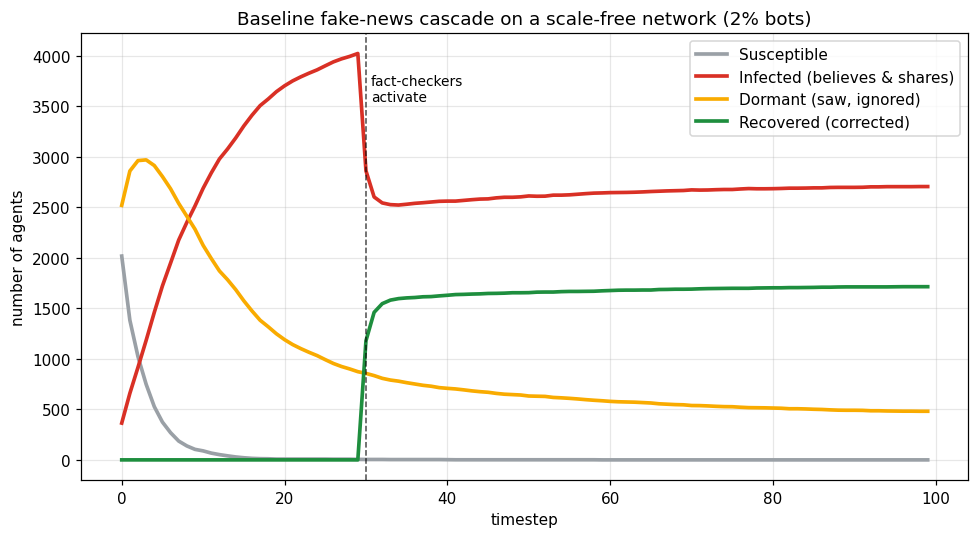

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"S": "#9aa0a6", "I": "#d93025", "D": "#f9ab00", "R": "#1e8e3e"}
labels = {"S": "Susceptible", "I": "Infected (believes & shares)",
          "D": "Dormant (saw, ignored)", "R": "Recovered (corrected)"}
for st in (S, I, D, R):
    ax.plot(df["t"], df[st], color=colors[st], lw=2.4, label=labels[st])
ax.axvline(30, color="black", ls="--", lw=1, alpha=0.7)
ax.text(30.6, df[["S", "I", "D", "R"]].values.max() * 0.95,
        "fact-checkers\nactivate", fontsize=9, va="top")
ax.set_xlabel("timestep"); ax.set_ylabel("number of agents")
ax.set_title("Baseline fake-news cascade on a scale-free network (2% bots)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The curve has the expected epidemic shape: a fast rise driven by the hub-mounted
bots, a peak, then a decline once the fact-checkers (dashed line) start turning
infected agents into Recovered ones. The agents left Dormant were exposed to the news
but never shared it.

## 8. Counterfactual — no fact-checkers

To see what the fact-checkers actually contribute, we run the same scenario with none
of them (`n_checkers=0`). Without a correction mechanism, no agent can reach the
Recovered state.

In [10]:
g_nc, agents_nc, _ = build_model(n_checkers=0, seed=RNG_SEED)
df_nc = run(g_nc, agents_nc, msg, steps=100, checker_activation=9999, seed=RNG_SEED)

population = sum(a.kind != "bot" for a in agents_nc.values())
print(f"population (all regular users) : {population}")
print(f"peak infected                  : {df_nc['I'].max()} "
      f"({100 * df_nc['I'].max() / population:.1f}%)")
print(f"still infected at the end      : {df_nc['I'].iloc[-1]}")
print(f"dormant at the end             : {df_nc['D'].iloc[-1]}")
print(f"recovered at the end           : {df_nc['R'].iloc[-1]}")
df_nc.tail(3)

population (all regular users) : 4900
peak infected                  : 4487 (91.6%)
still infected at the end      : 4487
dormant at the end             : 413
recovered at the end           : 0


,S,I,D,R,t
97,0,4486,414,0,97
98,0,4487,413,0,98
99,0,4487,413,0,99


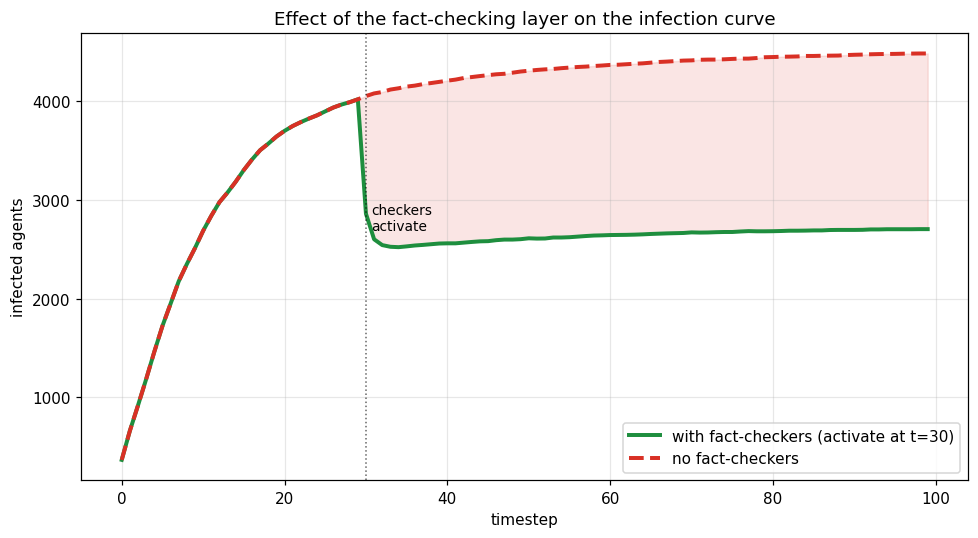

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df["t"], df["I"], color="#1e8e3e", lw=2.6,
        label="with fact-checkers (activate at t=30)")
ax.plot(df_nc["t"], df_nc["I"], color="#d93025", lw=2.6, ls="--",
        label="no fact-checkers")
ax.fill_between(df["t"], df["I"], df_nc["I"], color="#d93025", alpha=0.12)
ax.axvline(30, color="black", ls=":", lw=1, alpha=0.6)
ax.text(30.6, df_nc["I"].max() * 0.6, "checkers\nactivate", fontsize=9)
ax.set_xlabel("timestep"); ax.set_ylabel("infected agents")
ax.set_title("Effect of the fact-checking layer on the infection curve")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

With no fact-checkers the cascade never recedes — infected agents are never
corrected, so the curve plateaus near its peak instead of falling. The shaded area is
the share of misinformation that the fact-checking layer keeps in check. Recovery is
driven by the intervention, not by the diffusion process itself.

## 9. Network state map

The same run drawn on the graph. Node color shows the final state and node size
follows degree, so the hubs stand out; bots are the black squares. With 5,000 nodes the
plot is dense, so a cluster of one color reads as a region rather than single nodes.

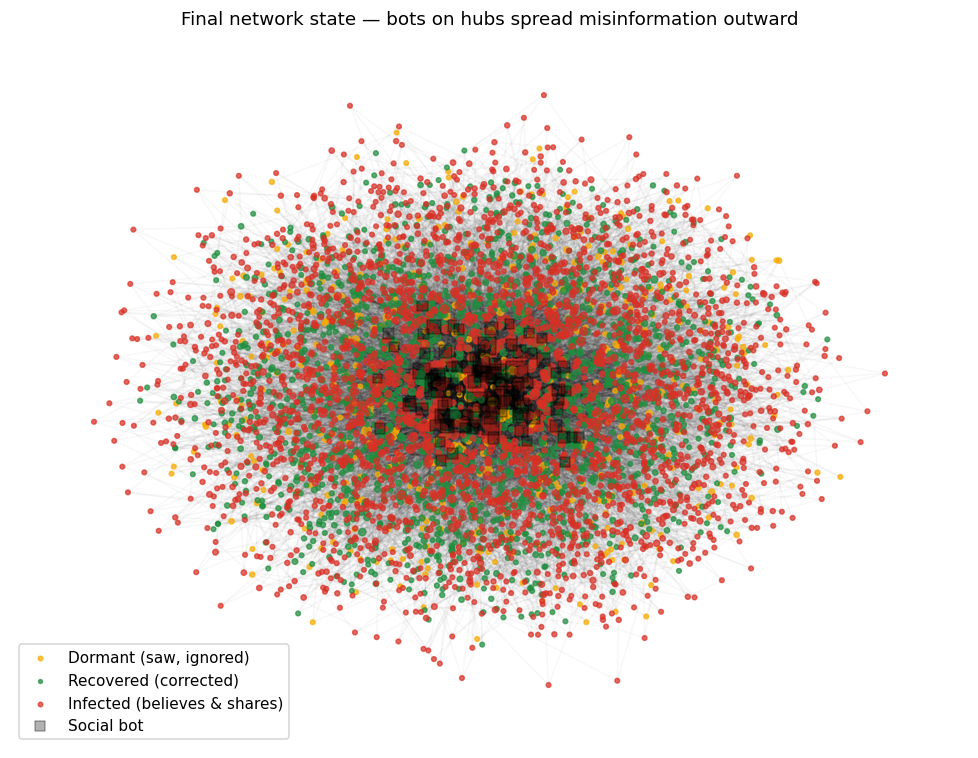

In [17]:
pos = nx.spring_layout(g, seed=RNG_SEED, k=0.15, iterations=40)
deg = dict(g.degree())
fig, ax = plt.subplots(figsize=(9, 7))
for st in (S, D, R, I):
    nodes = [n for n, a in agents.items() if a.kind != "bot" and a.state == st]
    nx.draw_networkx_nodes(g, pos, nodelist=nodes, node_color=colors[st],
                           node_size=[5 + 1.4 * deg[n] for n in nodes],
                           ax=ax, label=labels[st], alpha=0.7)
bot_nodes = [n for n, a in agents.items() if a.kind == "bot"]
nx.draw_networkx_nodes(g, pos, nodelist=bot_nodes, node_color="black",
                       node_shape="s", node_size=[5 + 1.4 * deg[n] for n in bot_nodes],
                       ax=ax, label="Social bot", alpha=0.3)
nx.draw_networkx_edges(g, pos, alpha=0.03, ax=ax)
ax.set_title("Final network state — bots on hubs spread misinformation outward")
ax.legend(scatterpoints=1, markerscale=0.6, loc="lower left"); ax.axis("off")
plt.tight_layout(); plt.show()

## 10. Experiment A — intervention timing

Here we change only when the fact-checkers switch on, and compare the runs against one
with no fact-checkers at all.

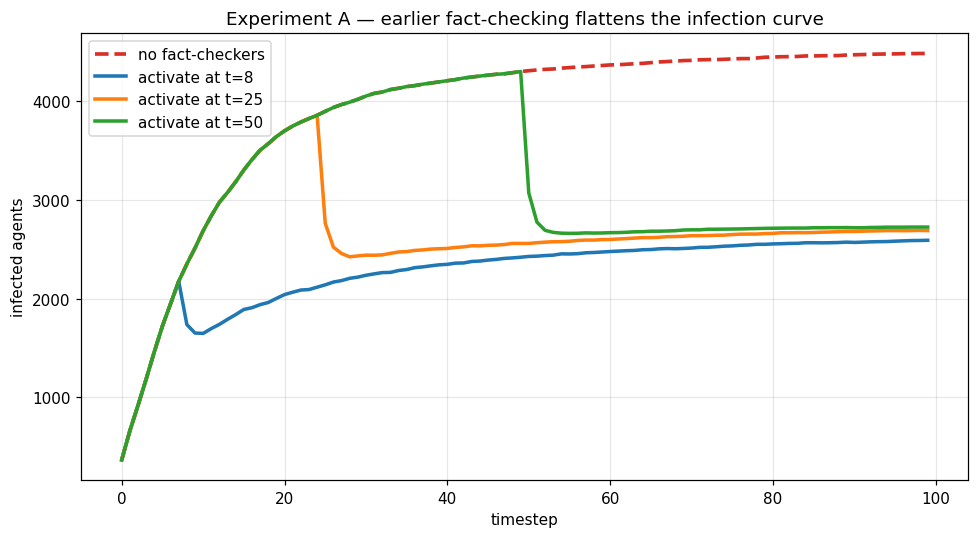

,scenario,peak_infected,final_infected
0,no fact-checkers,4487,4487
1,activate at t=8,2592,2592
2,activate at t=25,3860,2690
3,activate at t=50,4304,2726


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
rows = []

g0, a0, _ = build_model(n_checkers=0, seed=RNG_SEED)
d0 = run(g0, a0, msg, steps=100, checker_activation=9999, seed=RNG_SEED)
ax.plot(d0["t"], d0["I"], lw=2.4, color="#d93025", ls="--", label="no fact-checkers")
rows.append(dict(scenario="no fact-checkers", peak_infected=int(d0["I"].max()),
                 final_infected=int(d0["I"].iloc[-1])))

for activation in [8, 25, 50]:
    g2, a2, _ = build_model(seed=RNG_SEED)
    d2 = run(g2, a2, msg, steps=100, checker_activation=activation, seed=RNG_SEED)
    ax.plot(d2["t"], d2["I"], lw=2.3, label=f"activate at t={activation}")
    rows.append(dict(scenario=f"activate at t={activation}",
                     peak_infected=int(d2["I"].max()),
                     final_infected=int(d2["I"].iloc[-1])))

ax.set_xlabel("timestep"); ax.set_ylabel("infected agents")
ax.set_title("Experiment A — earlier fact-checking flattens the infection curve")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
pd.DataFrame(rows)

The earlier the fact-checkers act, the lower the infection peak. Delaying the
intervention lets the cascade run close to its unmitigated size before it is brought
under control.

## 11. Experiment B — critical thinking and bot targeting

Two more levers, side by side: how critically the population thinks (left), and whether
the bots sit on hubs or on random nodes (right).

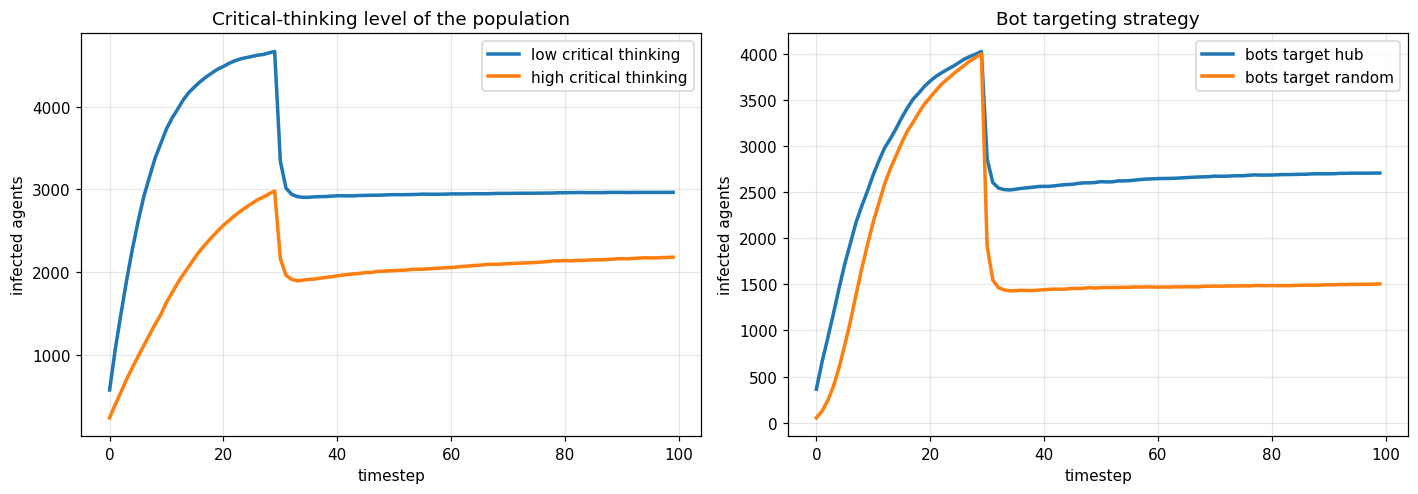

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for label, (ca, cb) in {"low critical thinking": (2, 5),
                         "high critical thinking": (5, 2)}.items():
    g3, a3, _ = build_model(seed=RNG_SEED, ct_a=ca, ct_b=cb)
    d3 = run(g3, a3, msg, steps=100, checker_activation=30, seed=RNG_SEED)
    axes[0].plot(d3["t"], d3["I"], lw=2.3, label=label)
axes[0].set_title("Critical-thinking level of the population")
axes[0].set_xlabel("timestep"); axes[0].set_ylabel("infected agents")
axes[0].legend(); axes[0].grid(alpha=0.3)

for target in ("hub", "random"):
    g4, a4, _ = build_model(seed=RNG_SEED, bot_target=target)
    d4 = run(g4, a4, msg, steps=100, checker_activation=30, seed=RNG_SEED)
    axes[1].plot(d4["t"], d4["I"], lw=2.3, label=f"bots target {target}")
axes[1].set_title("Bot targeting strategy")
axes[1].set_xlabel("timestep"); axes[1].set_ylabel("infected agents")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

A population with high critical thinking suppresses the cascade — the
critical-thinking term in the sharing rule works as a brake. And bots placed on hubs
spread the news faster and further than bots scattered at random.

## 12. Conclusions

The prototype runs end to end and behaves the way the design intended:

| Element | Outcome in the prototype |
|---|---|
| Extended SIR with a Dormant state | all four states populate and evolve sensibly |
| Three agent types on one network | users, bots and fact-checkers interact as expected |
| Weighted sharing rule | sharing responds realistically to agent attributes |
| Scale-free network with echo chambers | hub-mounted bots drive a disproportionate spread |
| Intervention timing | earlier fact-checking clearly lowers the peak |
| Critical thinking | a more critical population contains the cascade |
| Fact-checking layer | removing it stops the cascade from ever receding |

The core modeling assumptions are therefore feasible to implement. The full version is
outlined next.

## 13. Towards the full implementation

The prototype confirms the mechanics work. The full version turns it into a
configurable, interactive and statistically grounded tool.

### What changes

| Aspect | Prototype | Full version |
|---|---|---|
| Framework | a self-contained NetworkX loop | Mesa 3, for agent scheduling, data collection and batch runs |
| Echo chambers | a bimodal belief distribution | an explicit community-structured graph with tunable inter/intra-group linkage |
| Trust | a fixed trustworthiness attribute | a per-source trust value that updates as agents see corrections |
| Corrections | an instant state flip | correction messages that spread through the network and may not reach everyone |

The `Agent`, `Message`, `p_share` and `build_model` building blocks are written so this
port is mostly mechanical — the diffusion logic stays the same.

### Phase 1 — Mesa port and interactive dashboard

* Reimplement the three agent types as Mesa agents and move the loop into a Mesa model.
* Build an interactive dashboard with live sliders for the main parameters: number of
  agents, bot ratio, bot targeting, critical-thinking distribution, echo-chamber
  strength, fact-checker count and activation step, and message virality.
* Show the network and the infection curves updating live, with play / pause / step
  controls.
* Add an export panel to download a run as CSV and the plots as image files.

### Phase 2 — Statistical rigor

* Replace single-seed runs with repeated runs per configuration, so the curves carry
  confidence bands instead of being a single noisy line.
* Produce parameter-sweep heatmaps, for example bot ratio against critical thinking.
* Add richer metrics: cascade depth and breadth, time to peak, and infections per bot.


### Phase 3 — Experiments and write-up

* Run the full experiment set — bot targeting, critical-thinking levels, intervention
  timing, echo-chamber strength — with repeated runs.
* Optionally export an animation of the cascade spreading across the network.
* Write up the results.

### Open questions to settle

* Should Dormant agents stay re-infectable, as they are now, or become immune? Should
  fact-checkers be able to reach them too?
* Should corrections spread like content, or stay an instant flip?